# Swing+ Results

**2024-2025 Leaderboard : Top Swing+**

In [1]:
from pathlib import Path
import pandas as pd
import dataframe_image as dfi

ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / 'data').exists())
DATA = ROOT / 'data'
PLOTS = ROOT / 'results' / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)

MIN_SWINGS = 300   # qualify: >= 300 competitive swings in 2024-25 (2026 is the held-out test season)

# Swing+ = a batter's mean xrv_grade (per-swing xRV z-scored to a 0-100 scale, 50 = league-avg swing)
sw = pd.read_parquet(DATA / 'xrv_swings.parquet',
                     columns=['batter_id', 'game_year', 'xrv', 'xrv_grade'])
names = (pd.read_parquet(DATA / 'swings_model.parquet', columns=['batter_id', 'batter_full_name'])
           .drop_duplicates('batter_id'))

board = (sw[sw.game_year.isin([2024, 2025])]
         .groupby('batter_id')
         .agg(swings=('xrv_grade', 'size'),
              swing_plus=('xrv_grade', 'mean'),
              mean_xrv=('xrv', 'mean'))
         .reset_index()
         .query('swings >= @MIN_SWINGS')
         .merge(names, on='batter_id', how='left')
         .sort_values('swing_plus', ascending=False)
         .reset_index(drop=True))
board.index += 1
print(f'Qualified batters (>= {MIN_SWINGS} swings, 2024-25): {len(board)}')

top = board[['batter_full_name', 'swings', 'swing_plus', 'mean_xrv']].head(25)
top.columns = ['Batter', 'Swings', 'Swing+', 'mean xRV']
top = top.round({'Swing+': 1, 'mean xRV': 4})
dfi.export(top, str(PLOTS / 'swingplus_leaderboard.png'), table_conversion='matplotlib')
print('wrote', PLOTS / 'swingplus_leaderboard.png')
top

Qualified batters (>= 300 swings, 2024-25): 508


wrote C:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\swingplus_leaderboard.png


,Batter,Swings,Swing+,mean xRV
1,Patrick Wisdom,319,54.6,0.0071
2,Juan Soto,2004,53.8,0.0017
3,Matt Wallner,1166,53.4,-0.0007
4,Nick Kurtz,767,53.2,-0.0018
5,Christopher Morel,1584,52.9,-0.0037
6,Matt Mervis,321,52.7,-0.0055
7,Garrett Mitchell,497,52.7,-0.0055
8,Shohei Ohtani,2741,52.5,-0.0062
9,Kyle Schwarber,2219,52.5,-0.0068
10,Heriberto Hernández,481,52.4,-0.0073


**2024-2025 Leaderboard : Top Swing+ by swing-shape cluster**

In [2]:
# Top Swing+ by swing-shape cluster (per-(batter, stand) GMM; cluster 0 = the hitter's primary swing).
# Clusters are per-hitter and NOT comparable across hitters -- each row is one hitter's own shape.
# Archetype = Layer-1 league label + its situational tag (cards.py), so a bare "cluster 2" reads as
# e.g. "Uppercut Pull · down, vs offspd" -- two same-archetype shapes separate by their situation.
MIN_CLUSTER_SWINGS = 100

swp = pd.read_parquet(DATA / 'xrv_swings.parquet', columns=['play_id', 'game_year', 'xrv', 'xrv_grade'])
ca = pd.read_parquet(DATA / 'cluster_assignments.parquet',
                     columns=['play_id', 'batter_id', 'batter_stand', 'cluster'])
rep = pd.read_parquet(DATA / 'batter_repertoire.parquet',
                      columns=['batter_id', 'batter_stand', 'label'])
cards = pd.read_parquet(DATA / 'shape_cards.parquet',
                        columns=['batter_id', 'batter_stand', 'cluster', 'archetype_detailed'])

by_cluster = (ca.merge(swp, on='play_id', how='inner')
              .query('game_year in [2024, 2025]')
              .groupby(['batter_id', 'batter_stand', 'cluster'])
              .agg(swings=('xrv_grade', 'size'),
                   swing_plus=('xrv_grade', 'mean'),
                   mean_xrv=('xrv', 'mean'))
              .reset_index()
              .query('swings >= @MIN_CLUSTER_SWINGS')
              .merge(rep, on=['batter_id', 'batter_stand'], how='left')
              .merge(cards, on=['batter_id', 'batter_stand', 'cluster'], how='left')
              .sort_values('swing_plus', ascending=False)
              .reset_index(drop=True))
by_cluster.index += 1
print(f'Qualified (batter, cluster) shapes (>= {MIN_CLUSTER_SWINGS} swings, 2024-25): {len(by_cluster)}')

top_c = by_cluster[['label', 'cluster', 'archetype_detailed', 'swings', 'swing_plus', 'mean_xrv']].head(25)
top_c.columns = ['Batter', 'Cluster', 'Archetype (· situation)', 'Swings', 'Swing+', 'mean xRV']
top_c = top_c.round({'Swing+': 1, 'mean xRV': 4})
dfi.export(top_c, str(PLOTS / 'swingplus_by_cluster.png'), table_conversion='matplotlib')
print('wrote', PLOTS / 'swingplus_by_cluster.png')
top_c

Qualified (batter, cluster) shapes (>= 100 swings, 2024-25): 1380


wrote C:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\swingplus_by_cluster.png


,Batter,Cluster,Archetype (· situation),Swings,Swing+,mean xRV
1,Colson Montgomery,0,Primary,161,60.5,0.0443
2,Ryan McMahon,0,Primary,690,59.2,0.0358
3,Luis Robert Jr.,0,Primary,473,58.4,0.0313
4,Cal Raleigh (L),1,"Uppercut Pull · 3-2, ahead, down",518,58.4,0.0307
5,Patrick Wisdom,0,Primary,207,58.2,0.0298
6,Jake Bauers,0,Primary,405,58.2,0.0298
7,Shohei Ohtani,1,"Level Center · inside, vs FB, 0-0",750,58.2,0.0295
8,Christian Yelich,0,Primary,530,57.6,0.0258
9,Pete Alonso,1,"Level Center · down, inside",585,57.4,0.0244
10,Heriberto Hernández,0,Primary,241,57.4,0.0244


In [3]:
def cluster_table(batter_name):
    """Return a table of the batter's swing clusters (archetype + situational tag), sorted by Swing+."""
    d = by_cluster[by_cluster['label'].str.contains(batter_name, case=False, na=False)]
    return (d[['label', 'cluster', 'archetype_detailed', 'swings', 'swing_plus', 'mean_xrv']]
            .sort_values('swing_plus', ascending=False)
            .reset_index(drop=True)
            .rename(columns={'label': 'Batter', 'cluster': 'Cluster', 'archetype_detailed': 'Archetype (· situation)',
                             'swings': 'Swings', 'swing_plus': 'Swing+', 'mean_xrv': 'mean xRV'})
            .round({'Swing+': 1, 'mean xRV': 4}))

_ct = cluster_table('Raleigh')
dfi.export(_ct, str(PLOTS / 'swingplus_clusters_raleigh.png'), table_conversion='matplotlib')
print('wrote', PLOTS / 'swingplus_clusters_raleigh.png')
_ct

wrote C:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\swingplus_clusters_raleigh.png


,Batter,Cluster,Archetype (· situation),Swings,Swing+,mean xRV
0,Cal Raleigh (L),1,"Uppercut Pull · 3-2, ahead, down",518,58.4,0.0307
1,Cal Raleigh (L),0,Primary,546,54.4,0.0055
2,Cal Raleigh (R),0,Primary,392,53.8,0.0018
3,Cal Raleigh (R),1,"Uppercut Pull · down, vs offspd, inside",363,48.3,-0.0335
4,Cal Raleigh (L),3,"Level Oppo · up, vs FB, away",268,46.5,-0.0446
5,Cal Raleigh (L),4,"Uppercut Pull · down, vs offspd, away",131,42.9,-0.0677
6,Cal Raleigh (L),2,"Uppercut Pull · down, vs offspd, inside",350,40.3,-0.0843


**Swing Repertoire**

In [4]:
# Swing Repertoire leaderboard: Repertoire+ (repertoire expansiveness -- geometry only, how WIDE a
# hitter's swing-shape profile is) with each unit's Swing+ (value) merged in. The two are independent
# axes: Repertoire+ = breadth of shapes, Swing+ = mean quality of those swings.
# Repertoire+ is sorted high->low; lead with repertoire_pctile (0-100 rank) since single-shape units
# pile up at the 0-spread floor and skew the "100 = average" scale.
repertoire = pd.read_parquet(DATA / 'repertoire_scores.parquet',
                             columns=['batter_id', 'batter_stand', 'label', 'k',
                                      'repertoire_plus', 'repertoire_pctile'])

# unit-level Swing+ = mean xrv_grade over the unit's 2024-25 swings, keyed per (batter_id, batter_stand)
swp = pd.read_parquet(DATA / 'xrv_swings.parquet', columns=['play_id', 'game_year', 'xrv_grade'])
ca = pd.read_parquet(DATA / 'cluster_assignments.parquet',
                     columns=['play_id', 'batter_id', 'batter_stand'])
unit_swing_plus = (ca.merge(swp, on='play_id', how='inner')
                   .query('game_year in [2024, 2025]')
                   .groupby(['batter_id', 'batter_stand'])['xrv_grade']
                   .mean().rename('swing_plus').reset_index())

board = (repertoire.merge(unit_swing_plus, on=['batter_id', 'batter_stand'], how='left')
         .sort_values('repertoire_plus', ascending=False)
         .reset_index(drop=True))
board.index += 1
print(f'Qualified (batter, stand) units: {len(board)}')

lead = board[['label', 'batter_stand', 'k', 'repertoire_plus', 'swing_plus']].head(25)
lead.columns = ['Batter', 'R/L', 'Shapes (k)', 'Repertoire+', 'Swing+']
lead = lead.round({'Repertoire+': 1, 'Swing+': 1})
dfi.export(lead, str(PLOTS / 'repertoire_leaderboard.png'), table_conversion='matplotlib')
print('wrote', PLOTS / 'repertoire_leaderboard.png')
lead

Qualified (batter, stand) units: 703
wrote C:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\repertoire_leaderboard.png


,Batter,R/L,Shapes (k),Repertoire+,Swing+
1,Johnathan Rodríguez,R,2,65.8,48.9
2,Spencer Jones,L,2,63.9,47.0
3,Rece Hinds,R,2,62.3,48.8
4,Bobby Dalbec,R,2,62.1,50.2
5,Riley Adams,R,2,61.6,49.5
6,Michael Toglia (R),R,2,61.5,50.4
7,Brandon Lockridge,R,2,61.4,49.2
8,Abraham Toro (R),R,2,61.4,49.8
9,Kristian Campbell,R,2,61.4,50.3
10,Konnor Griffin,R,2,61.4,NaN


## Validation

Four checks on the bespoke xRV / Swing+ pipeline:

1. **Year over year** — per-season agreement of predicted (`xrv`) and tables-realized (`realized_rv`) run value against the `delta_run_exp` anchor (models train on 2024–25; **2026 is held out**), then Swing+ reliability across consecutive seasons (is it a stable batter skill?).
2. **Expected vs actual** — batter-level scatter of mean predicted xRV against mean actual `delta_run_exp`.
3. **Feature importance** — gain per feature for each of the three models (`p_bip`, `p_foul`, `v_bip`), loaded from `data/xrv_models/` (produced by `src/xRV_model.py`).
4. **Predictive validity** — faceted scatter of Swing+ against real hitting outcomes (BA, OPS, wRC+, wOBA, WAR) from `season_stats_hitting`, one panel per metric with its Pearson r. *OPS+ is not stored in `mlb_db`; wRC+ is the park/league-adjusted analog and stands in for it.*

In [5]:
# ---- Validation setup + year-over-year model agreement ----
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error

# Full per-swing xRV table: predicted (xrv), tables-realized (realized_rv), and the actual anchor (delta_run_exp)
val = pd.read_parquet(DATA / 'xrv_swings.parquet',
                      columns=['batter_id', 'batter_stand', 'game_year', 'balls', 'strikes',
                               'xrv', 'realized_rv', 'delta_run_exp', 'xrv_grade'])
print(f'{len(val):,} swings | seasons {sorted(val.game_year.unique())}')

# (a) Per-season agreement with delta_run_exp. Models train on 2024-25; 2026 is the held-out test season.
m = val.dropna(subset=['delta_run_exp'])
per_season = (m.groupby('game_year')
              .apply(lambda g: pd.Series({
                  'swings': len(g),
                  'corr(xRV, actual)': np.corrcoef(g['xrv'], g['delta_run_exp'])[0, 1],
                  'corr(realized, actual)': np.corrcoef(g['realized_rv'], g['delta_run_exp'])[0, 1],
                  'rmse(realized, actual)': root_mean_squared_error(g['delta_run_exp'], g['realized_rv']),
                  'mean xRV': g['xrv'].mean()}), include_groups=False)
              .round(4))
per_season['swings'] = per_season['swings'].astype(int)
dfi.export(per_season, str(PLOTS / 'xrv_per_season_validation.png'), table_conversion='matplotlib')
print('wrote', PLOTS / 'xrv_per_season_validation.png', '  (2026 = held-out test season)')
per_season

795,723 swings | seasons [np.int64(2024), np.int64(2025), np.int64(2026)]
wrote C:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\xrv_per_season_validation.png   (2026 = held-out test season)


,swings,"corr(xRV, actual)","corr(realized, actual)","rmse(realized, actual)",mean xRV
game_year,,,,,
2024,306933,0.2141,0.9576,0.0898,-0.0230
2025,325272,0.2150,0.9569,0.0912,-0.0221
2026,163512,0.2016,0.9565,0.0914,-0.0217


In [6]:
# (b) Year-over-year reliability: is Swing+ a stable batter skill? Correlate each batter's Swing+
# across consecutive seasons (batters with >= 200 tracked swings in both years).
MIN_SW = 200
sp = (val.groupby(['batter_id', 'game_year'])
        .agg(swings=('xrv_grade', 'size'), swing_plus=('xrv_grade', 'mean'))
        .reset_index().query('swings >= @MIN_SW'))
wide = sp.pivot(index='batter_id', columns='game_year', values='swing_plus')
rel = []
for a, b in [(2024, 2025), (2025, 2026)]:
    d = wide[[a, b]].dropna()
    rel.append({'season pair': f'{a} -> {b}', 'batters': len(d), 'Swing+ corr': np.corrcoef(d[a], d[b])[0, 1]})
yoy_reliability = pd.DataFrame(rel).set_index('season pair').round(3)
dfi.export(yoy_reliability, str(PLOTS / 'swingplus_yoy_reliability.png'), table_conversion='matplotlib')
print('wrote', PLOTS / 'swingplus_yoy_reliability.png')
yoy_reliability

wrote C:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\swingplus_yoy_reliability.png


,batters,Swing+ corr
season pair,,
2024 -> 2025,340,0.740
2025 -> 2026,284,0.712


wrote C:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\xrv_feature_importance.png


,p_bip,p_foul,v_bip
balls,1.3,2.8,2.0
strikes,4.6,4.6,2.6
same_hand,3.4,3.5,2.4
plate_x_pull,8.4,12.2,15.6
plate_z_norm,14.6,23.3,6.0
pitch_type,8.5,5.0,5.8
swing_path_tilt,5.9,4.6,3.6
swing_length,4.0,11.8,11.3
bat_speed,2.9,8.6,29.1
vert_attack_angle,13.1,10.9,12.0


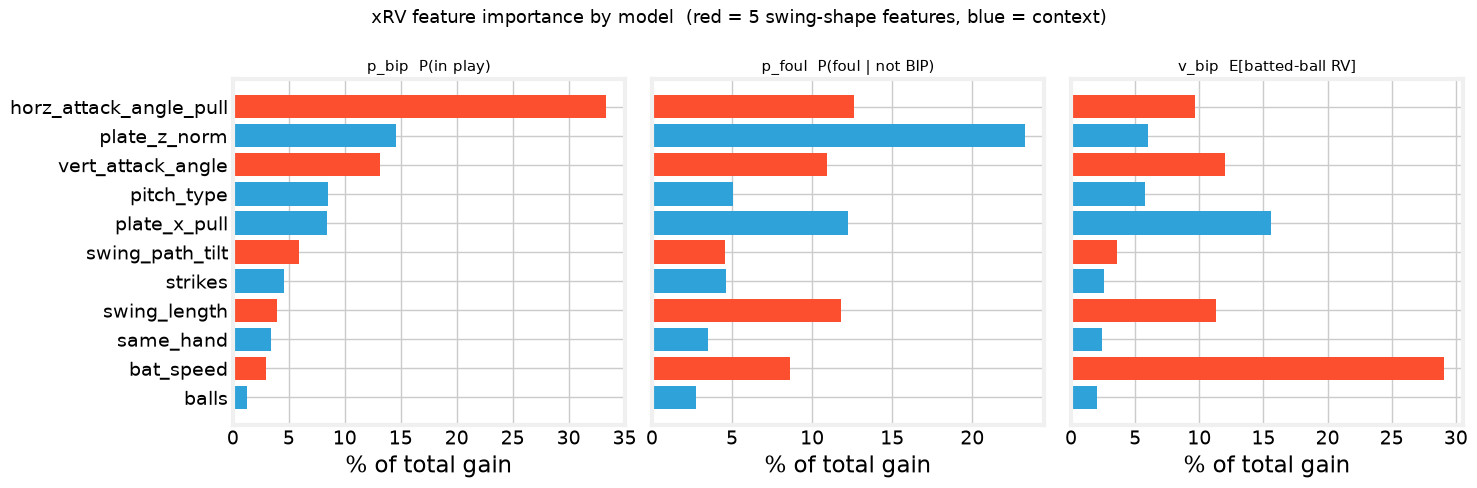

In [7]:
# ---- Feature importance per model (gain), models loaded from src/xRV_model.py's outputs ----
# Three separate models share the same 11 predictors; we plot each one's gain split.
import sys
import xgboost as xgb
sys.path.insert(0, str(ROOT / 'src'))
from xRV_model import FEATURES, SHAPE_FEATURES, MODEL_DIR   # 11 shared predictors + saved-model dir

def gain(name):
    b = xgb.Booster()
    b.load_model(str(MODEL_DIR / f'{name}.json'))
    s = pd.Series(b.get_score(importance_type='gain')).reindex(FEATURES).fillna(0.0)
    return 100 * s / s.sum()   # % of total gain

MODELS = {'p_bip': 'p_bip  P(in play)',
          'p_foul': 'p_foul  P(foul | not BIP)',
          'v_bip': 'v_bip  E[batted-ball RV]'}
imp = pd.DataFrame({n: gain(n) for n in MODELS})

FT = ['fivethirtyeight', {'figure.facecolor': 'white', 'axes.facecolor': 'white',
                          'savefig.facecolor': 'white', 'grid.color': '#cbcbcb'}]
with plt.style.context(FT):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for ax, name in zip(axes, MODELS):
        d = imp[name].sort_values()
        colors = ['#fc4f30' if f in SHAPE_FEATURES else '#30a2da' for f in d.index]  # red = shape, blue = context
        ax.barh(d.index, d.values, color=colors)
        ax.set_title(MODELS[name], fontsize=11)
        ax.set_xlabel('% of total gain')
    fig.suptitle('xRV feature importance by model  (red = 5 swing-shape features, blue = context)', fontsize=13)
    fig.tight_layout()
    fig.savefig(PLOTS / 'xrv_feature_importance.png', dpi=130)
print('wrote', PLOTS / 'xrv_feature_importance.png')
imp.round(1)

Batter-seasons: 967 (>= 150 tracked swings & >= 200 PA), MLB regular season 2024-26


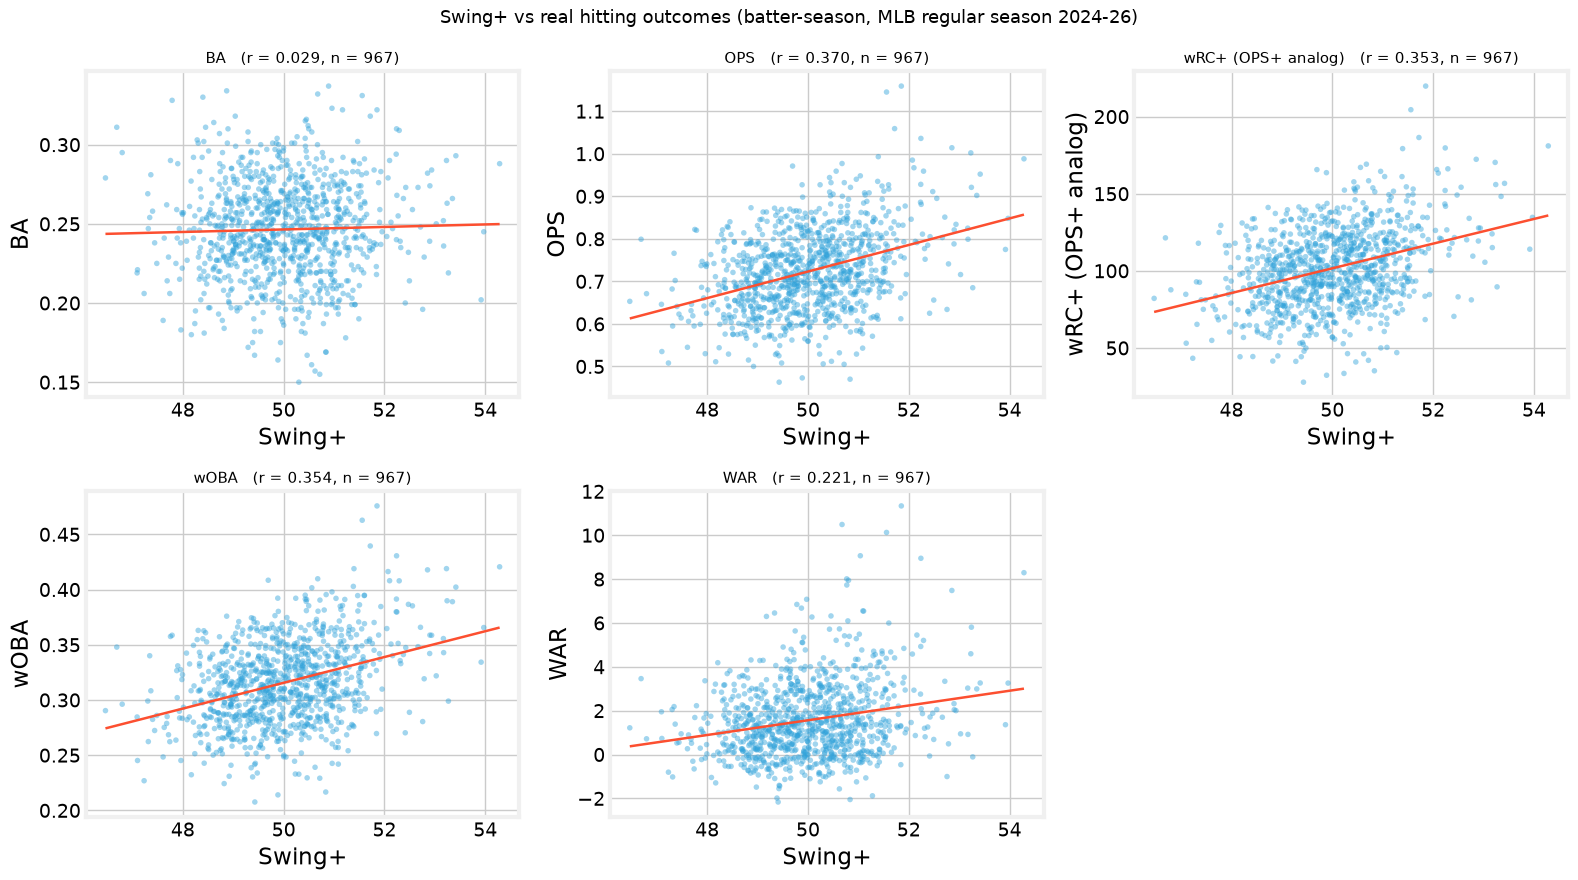

wrote C:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\swingplus_predictive_scatter.png


In [8]:
# ---- Predictive validity: does Swing+ track real hitting outcomes? ----
# OPS+ is NOT stored in mlb_db. wRC+ (wrc_plus) is the park/league-adjusted analog (100 = avg), so it
# stands in for OPS+ here. We pull season_stats_hitting (MLB, regular season) and scatter Swing+
# against each outcome per (batter, season), one faceted panel each with its Pearson r + OLS fit.
import os, re, warnings
import mysql.connector
warnings.filterwarnings('ignore', message='pandas only supports SQLAlchemy')

def get_secret(name):
    v = os.environ.get(name)
    if v:
        return v
    ef = Path.home() / '.claude' / '.env'
    if ef.exists():
        for line in ef.read_text(encoding='utf-8', errors='ignore').splitlines():
            m = re.match(rf'^\s*{re.escape(name)}\s*=\s*(.+)$', line)
            if m:
                return m.group(1).strip().strip('"').strip("'")
    return None

cn = mysql.connector.connect(host=get_secret('BIOMECH_DB_HOST'), port=int(get_secret('BIOMECH_DB_PORT') or 3306),
                             user=get_secret('BIOMECH_DB_USER'), password=get_secret('BIOMECH_DB_PASS'), database='mlb_db')
stats = pd.read_sql("""SELECT season AS game_year, mlbam_id AS batter_id, pa,
    ba, ops, wrc_plus, woba, war
    FROM season_stats_hitting
    WHERE level_id = 1 AND game_type = 'R' AND season IN (2024, 2025, 2026)""", cn)
cn.close()

MIN_SW, MIN_PA = 150, 200
bs = (val.groupby(['batter_id', 'game_year'])
        .agg(swings=('xrv_grade', 'size'), swing_plus=('xrv_grade', 'mean'))
        .reset_index().query('swings >= @MIN_SW'))
mrg = bs.merge(stats, on=['batter_id', 'game_year'], how='inner').query('pa >= @MIN_PA')
print(f'Batter-seasons: {len(mrg)} (>= {MIN_SW} tracked swings & >= {MIN_PA} PA), MLB regular season 2024-26')

# wRC+ is the OPS+ analog (OPS+ not in mlb_db). One panel per outcome, Swing+ on x.
targets = {'ba': 'BA', 'ops': 'OPS', 'wrc_plus': 'wRC+ (OPS+ analog)', 'woba': 'wOBA', 'war': 'WAR'}
FT = ['fivethirtyeight', {'figure.facecolor': 'white', 'axes.facecolor': 'white',
                          'savefig.facecolor': 'white', 'grid.color': '#cbcbcb'}]
with plt.style.context(FT):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, (col, lab) in zip(axes.flat, targets.items()):
        d = mrg[['swing_plus', col]].dropna()
        r = d['swing_plus'].corr(d[col])
        slope, intercept = np.polyfit(d['swing_plus'], d[col], 1)
        xs = np.array([d['swing_plus'].min(), d['swing_plus'].max()])
        ax.scatter(d['swing_plus'], d[col], s=16, alpha=.45, color='#30a2da', edgecolor='none')
        ax.plot(xs, intercept + slope * xs, color='#fc4f30', lw=1.8)
        ax.set_title(f'{lab}   (r = {r:.3f}, n = {len(d)})', fontsize=11)
        ax.set_xlabel('Swing+')
        ax.set_ylabel(lab)
    axes.flat[-1].axis('off')   # 5 metrics in a 2x3 grid -> hide the empty 6th panel
    fig.suptitle('Swing+ vs real hitting outcomes (batter-season, MLB regular season 2024-26)', fontsize=13)
    fig.tight_layout()
    fig.savefig(PLOTS / 'swingplus_predictive_scatter.png', dpi=130)
    plt.show()
print('wrote', PLOTS / 'swingplus_predictive_scatter.png')